# ACD example: DHP (`design="dhp"`) on ImprovedB747Env

This notebook demonstrates **DHP** (Dual Heuristic Programming) from Prokhorov & Wunsch.

- Critic learns \(\lambda = \partial J/\partial R\).
- Actor is updated using model Jacobians \(A,B\) and the critic’s \(\lambda\).

For tracking tasks we use \(R(t)=[x(t),\theta_{ref}(t),q_{ref}(t)]\).



In [1]:
import sys
from pathlib import Path

HERE = Path.cwd().resolve()
ROOT = HERE if (HERE / "tensoraerospace").exists() else HERE.parents[2]
EX_DIR = ROOT / "example" / "dynamic-programming"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(EX_DIR))

import numpy as np

from tensoraerospace.agent import ADP
from acd_b747_common import make_env_b747_sine, plot_rollout, rollout

print("repo root:", ROOT)



repo root: /Users/asmazaev


In [4]:
# ---- User controls ----
DT = 0.1
N_STEPS = 300
REWARD_MODE = "tracking"

SINE_AMP_DEG = 1.0
SINE_FREQ_HZ = 0.05

DESIGN = "dhp"
DEVICE = "mps"
GAMMA = 0.99
HIDDEN_SIZE = 64

ACTOR_LR = 5e-5
CRITIC_LR = 1e-4
EXPLORATION_STD = 0.02

# Baseline controller (practical stabilizer) settings.
# In the paper, this is used as an INITIAL stabilizing actor so the critic can adapt
# on stable trajectories. It is not part of the DHP/GDHP equations.
BASELINE_TYPE = "pid"  # "pid" or "pd" (used for warm-start + evaluation baseline)
BASELINE_KP = -24.6295
BASELINE_KI = -0.2486
BASELINE_KD = -7.8179
BASELINE_PID_MODE = "deg"  # "deg" or "norm"

# Paper-style warm start: initialize actor by imitating the stabilizing baseline,
# then continue training with pure ACD updates (no baseline residual composition).
DHP_WARMSTART_ACTOR_EPISODES = 10
DHP_WARMSTART_ACTOR_EPOCHS = 5
DHP_WARMSTART_DISABLE_BASELINE_AFTER = True

# Residual baseline composition (optional). If enabled, action is composed as:
#   u = u_baseline + DHP_RESIDUAL_SCALE * delta
# For a pure (no-baseline) policy, keep DHP_USE_BASELINE=False.
DHP_USE_BASELINE = False
DHP_RESIDUAL_SCALE = 1.0
DHP_ACTOR_DELTA_L2 = 0.0

# Alternating training cycles (Section III)
DHP_CRITIC_CYCLE_EPISODES = 5
DHP_ACTION_CYCLE_EPISODES = 1

TRAIN_EPISODES = 300
MAX_STEPS_PER_EPISODE = N_STEPS



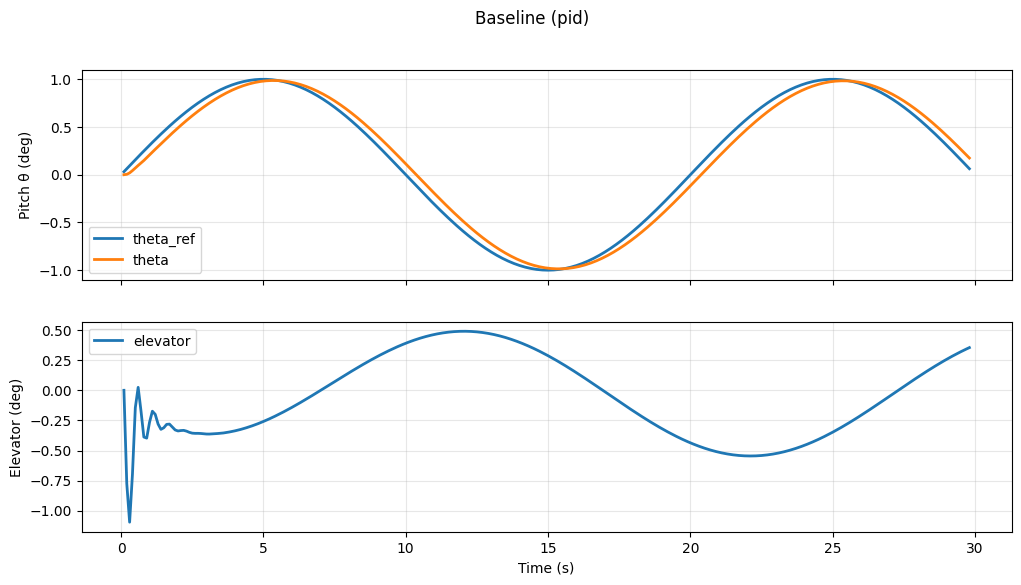

metrics: {'rmse_theta_deg': 0.0802350392390373, 'mae_theta_deg': 0.07220536125471347, 'max_abs_theta_deg': 0.1180310721167619, 'episode_return': -0.002675393092135702}
Training... episodes= 300 design= dhp


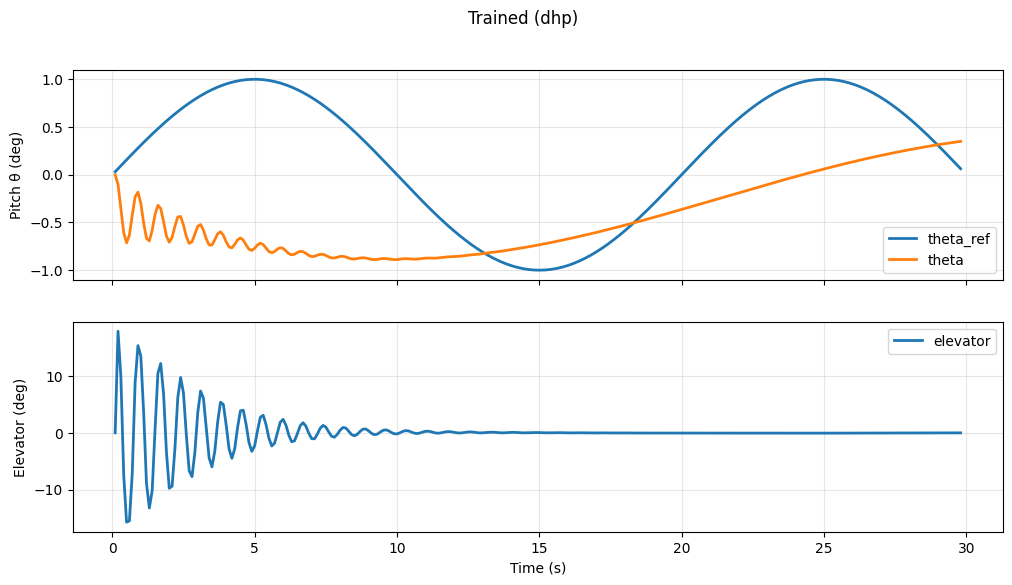

metrics: {'rmse_theta_deg': 0.9237964389566201, 'mae_theta_deg': 0.7462011059103418, 'max_abs_theta_deg': 1.7998752454883113, 'episode_return': -0.38880952705788796}


In [5]:
def make_env():
    return make_env_b747_sine(
        dt=DT,
        n_steps=N_STEPS,
        reward_mode=REWARD_MODE,
        sine_amp_deg=SINE_AMP_DEG,
        sine_freq_hz=SINE_FREQ_HZ,
    )

# Baseline (comparison only)
base_kind = str(BASELINE_TYPE).lower().strip()
baseline = rollout(
    make_env(),
    agent=None,
    baseline=base_kind,
    pid_kp=BASELINE_KP,
    pid_ki=BASELINE_KI,
    pid_kd=BASELINE_KD,
    pid_mode=BASELINE_PID_MODE,
    pd_kp=BASELINE_KP,
    pd_kd=BASELINE_KD,
)
plot_rollout(baseline, title=f"Baseline ({base_kind})")

agent = ADP(
    env=make_env(),
    design=DESIGN,
    gamma=GAMMA,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    hidden_size=HIDDEN_SIZE,
    device=DEVICE,
    exploration_std=EXPLORATION_STD,
    # Baseline settings (used for warm-start and/or residual composition if enabled)
    dhp_use_baseline=bool(DHP_USE_BASELINE),
    dhp_baseline_type=base_kind,
    dhp_baseline_kp=BASELINE_KP,
    dhp_baseline_ki=BASELINE_KI,
    dhp_baseline_kd=BASELINE_KD,
    dhp_pid_mode=BASELINE_PID_MODE,
    # Paper-style warm start: initialize actor as stabilizing controller, then train ACD
    dhp_warmstart_actor_episodes=int(DHP_WARMSTART_ACTOR_EPISODES),
    dhp_warmstart_actor_epochs=int(DHP_WARMSTART_ACTOR_EPOCHS),
    dhp_warmstart_actor_disable_baseline_after=bool(DHP_WARMSTART_DISABLE_BASELINE_AFTER),
    # Policy scaling / residual scaling
    dhp_residual_scale=float(DHP_RESIDUAL_SCALE),
    dhp_actor_delta_l2=float(DHP_ACTOR_DELTA_L2),
    # Alternating training cycles (Section III)
    dhp_critic_cycle_episodes=int(DHP_CRITIC_CYCLE_EPISODES),
    dhp_action_cycle_episodes=int(DHP_ACTION_CYCLE_EPISODES),
    log_every_updates=500,
)

print("Training...", "episodes=", TRAIN_EPISODES, "design=", DESIGN)
agent.train(num_episodes=int(TRAIN_EPISODES), max_steps=int(MAX_STEPS_PER_EPISODE))

trained = rollout(make_env(), agent=agent, deterministic=True)
plot_rollout(trained, title=f"Trained ({DESIGN})")

